In [1]:
from engine import Value
from visualize import draw_graph

In [2]:
a = Value(2, label='a')
b = a.exp(); b.label='b'
b**2

Value: 54.59815003314424 | Label: 

In [3]:
a = Value(9, label="a")
b = Value(3, label="b")
c = a+b; c.label = "c"
d = Value(-4, label="d")
e = Value(-6, label="e")
f = d*e; f.label="f"
g = c/f; g.label="g"
o = g.tanh(); o.label='o'

### Before Backward Propagation

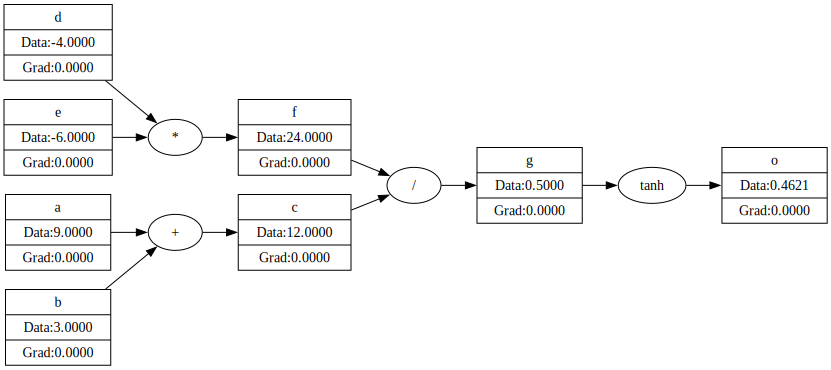

In [4]:
draw_graph(o)

### After Backward Propagation

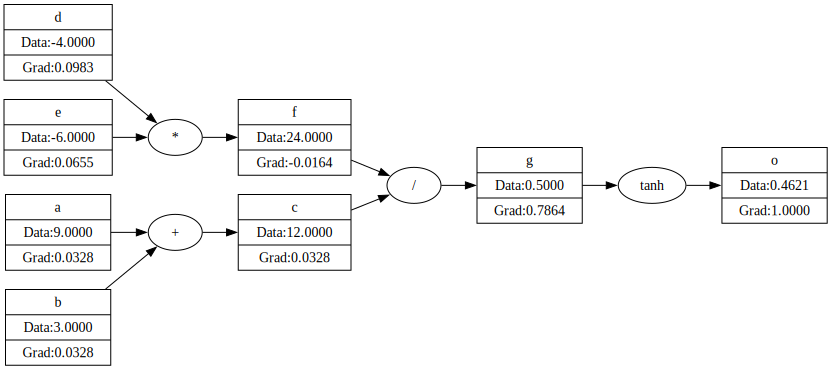

In [5]:
o.backward()
draw_graph(o)

In [6]:
a = Value(0.2, label="a")
b = Value(3, label="b")
c = a+b; c.label="c"
d = a*b; d.label="d"
e = c*d; e.label="e"
o = e.tanh(); o.label="o"

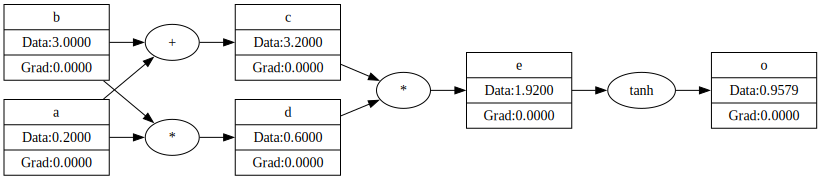

In [7]:
draw_graph(o)

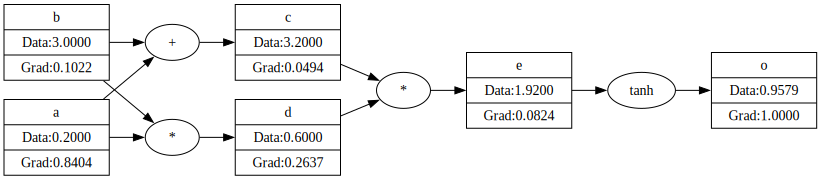

In [8]:
o.backward()
draw_graph(o)

In [9]:
from neural_network import MLP
    
mlp = MLP(3, [4, 4, 5, 1])

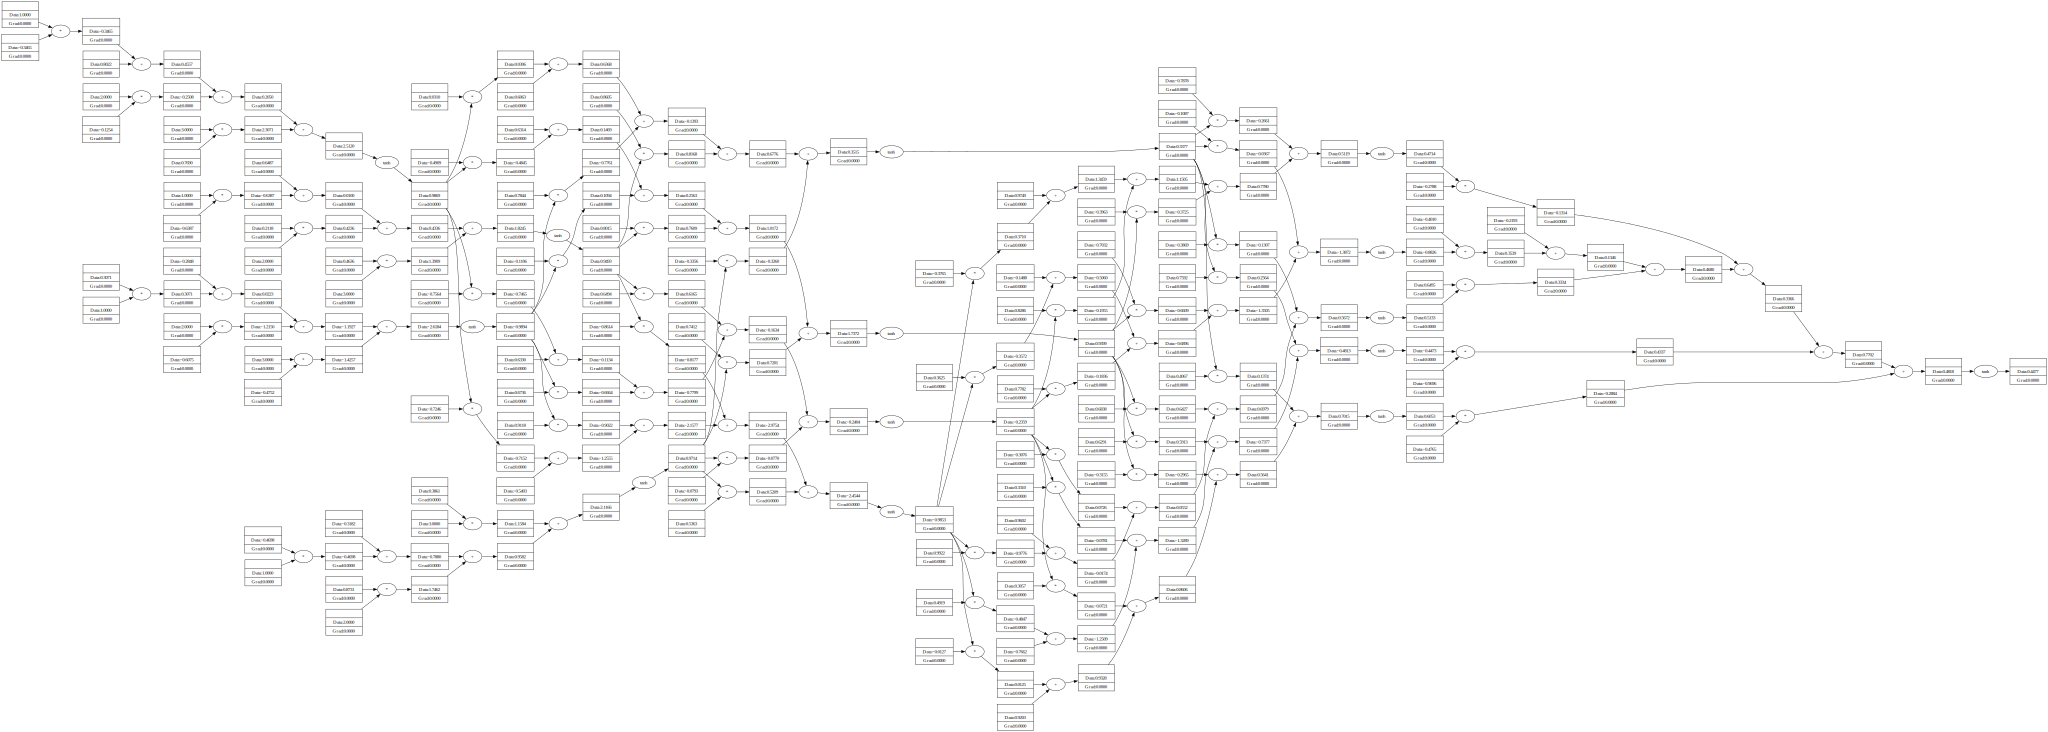

In [10]:
x = [1,2,3]
draw_graph(mlp(x))

In [11]:
xs = [
    [2, 3, -1],
    [4, -3.5, -2],
    [-6, 0.5, 2.3],
    [1, -3, 4.3]
]

y = [1, -1, -1, 1]
y_pred = [mlp(x) for x in xs]

In [12]:
y_pred

[Value: 0.4706027318924377 | Label: ,
 Value: -0.7073977831412502 | Label: ,
 Value: 0.42498813980367905 | Label: ,
 Value: -0.5314596024872807 | Label: ]

In [13]:
mse = sum((yp-yi)**2 for yp, yi in zip(y_pred, y))  #MSE
rmse = mse**(1/2)
print(f"Mean Square Error: {mse} & Root Mean Square Error: {rmse}")

Mean Square Error: Value: 4.741837237422056 | Label:  & Root Mean Square Error: Value: 2.177576000377956 | Label: 


#### Backward Pass

In [14]:
rmse.backward()

#### Forward Pass

In [15]:
mlp.forward_pass(0.01)
y_pred = [mlp(x) for x in xs]
mse = sum((yp-yi)**2 for yp, yi in zip(y_pred, y))  #MSE
rmse = mse**(1/2)

In [16]:
print(f"Mean Square Error: {mse} & Root Mean Square Error: {rmse}")  #Loss Decreased

Mean Square Error: Value: 4.574440911814099 | Label:  & Root Mean Square Error: Value: 2.138794265892374 | Label: 


#### Try Epochs

In [17]:
mses = []
rmses = []
for i in range(100):
    y_pred = [mlp(x) for x in xs]
    mse = sum((yp-yi)**2 for yp, yi in zip(y_pred, y))  #MSE
    rmse = mse**(1/2)
    mses.append(mse.data)
    rmses.append(rmse.data)
    for p in mlp.parameters():
        p.grad = 0

    rmse.backward()
    mlp.forward_pass(0.01)

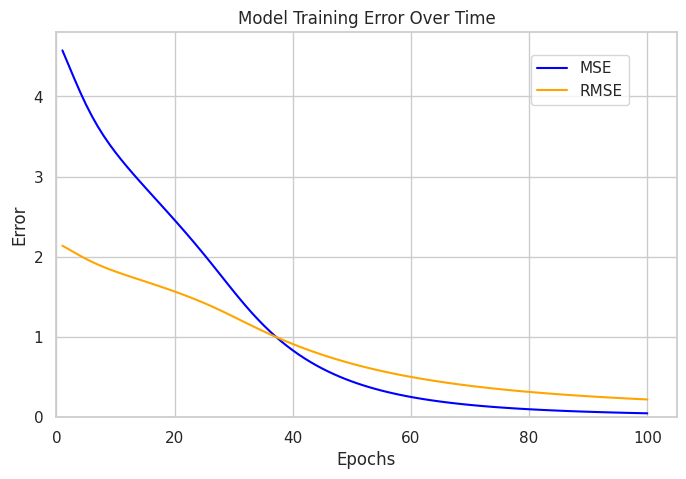

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt

epochs = [i+1 for i in range(100)]

sns.set_theme(style="whitegrid")

fig, ax1 = plt.subplots(figsize=(8, 5))
sns.lineplot(x=epochs, y=mses, ax=ax1, color="blue", label="MSE")

sns.lineplot(x=epochs, y=rmses, ax=ax1, color="orange", label="RMSE")

# 4. Final adjustments
ax1.set_ylabel("Error")
ax1.set_xlabel("Epochs")
ax1.set_xbound(0, )
ax1.set_ybound(0, )
ax1.get_legend().remove()  # Avoid separate overlapping legends
fig.legend(loc="upper right", bbox_to_anchor=(0.85, 0.85))
plt.title("Model Training Error Over Time")
plt.show()

In [19]:
mlp

MLP(
  Layer(inputs=3, outputs=4) with Neuron(inputs=3, activation='tanh'),
  Layer(inputs=4, outputs=4) with Neuron(inputs=4, activation='tanh'),
  Layer(inputs=4, outputs=5) with Neuron(inputs=4, activation='tanh'),
  Layer(inputs=5, outputs=1) with Neuron(inputs=5, activation='tanh')
)